# Week 11b — Faithful EEGNet and Subject-Level Analysis

## Goal

Week 11 established that the current EEGNet configuration is reproducible.

The selected Configuration D achieved approximately:

**Validation BA = 0.628 ± 0.002**

across five random seeds.

However, the current implementation does not include the max-norm constraints
used by the documented EEGNet implementation.

This notebook performs one final bounded EEGNet-development experiment before
the model is frozen.

### Phase 3A — EEGNet constraints

Compare the current Configuration D against the same model with the documented
EEGNet max-norm constraints:

- depthwise spatial convolution: max norm = 1.0
- final classifier: max norm = 0.25

Everything else remains fixed.

### Phase 3B — Subject-level analysis

Evaluate validation balanced accuracy separately for each of the 16 unseen
validation subjects.

This will determine whether the overall performance near 0.63 represents:

- similar performance across most subjects, or
- large differences between individual subjects.

The 17 held-out test subjects remain untouched.

### Imports

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import balanced_accuracy_score

### Paths and configurations

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

BATCH_SIZE = 32
LEARNING_RATE = 1e-3
DROPOUT = 0.5
WEIGHT_DECAY = 1e-4
N_EPOCHS = 30

SEEDS = [42, 123, 456, 789, 2026]

print("Device:", DEVICE)

Device: mps


### Load data and split

In [3]:
X = np.load(
    DATA_DIR / "X_motor_imagery.npy",
    mmap_mode="r"
)

y = np.load(
    DATA_DIR / "y_motor_imagery.npy",
    mmap_mode="r"
)

subjects = np.load(
    DATA_DIR / "subjects.npy",
    mmap_mode="r"
)

split_df = pd.read_csv(
    RESULTS_DIR / "week9_subject_split.csv"
)

train_subjects = split_df.loc[
    split_df["split"] == "train",
    "subject"
].to_numpy()

val_subjects = split_df.loc[
    split_df["split"] == "validation",
    "subject"
].to_numpy()

train_indices = np.where(
    np.isin(subjects, train_subjects)
)[0]

val_indices = np.where(
    np.isin(subjects, val_subjects)
)[0]

### Load week 1 results

In [4]:
week11_results = pd.read_csv(
    RESULTS_DIR / "week11_config_results.csv"
)

config_d_results = (
    week11_results[
        week11_results["config"] == "D"
    ]
    .sort_values("seed")
    .reset_index(drop=True)
)

config_d_results

,config,seed,best_val_ba,best_epoch
0,D,42,0.627701,19
1,D,123,0.627926,17
2,D,456,0.628144,28
3,D,789,0.631745,30
4,D,2026,0.626715,22


In [5]:
print(
    "Configuration D mean BA:",
    config_d_results["best_val_ba"].mean()
)

print(
    "Configuration D SD:",
    config_d_results["best_val_ba"].std()
)

Configuration D mean BA: 0.6284463487332339
Configuration D SD: 0.0019232810519355748


### Check data

In [6]:
print("X shape:", X.shape)
print("Training subjects:", len(train_subjects))
print("Training trials:", len(train_indices))
print("Validation subjects:", len(val_subjects))
print("Validation trials:", len(val_indices))
print("Baseline runs:", len(config_d_results))

X shape: (4898, 64, 481)
Training subjects: 76
Training trials: 3423
Validation subjects: 16
Validation trials: 718
Baseline runs: 5


### Dataset class

In [7]:
class EEGNetDataset(Dataset):
    def __init__(self, X, y, indices):
        self.X = X
        self.y = y
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        trial_index = self.indices[index]

        x = torch.tensor(
            self.X[trial_index],
            dtype=torch.float32
        ) * 1e6

        x = x.unsqueeze(0)

        y = torch.tensor(
            self.y[trial_index],
            dtype=torch.long
        )

        return x, y


train_dataset = EEGNetDataset(X, y, train_indices)
val_dataset = EEGNetDataset(X, y, val_indices)

### Constrained EEGNet class

In [8]:
class ConstrainedEEGNet(nn.Module):
    def __init__(
        self,
        n_channels=64,
        n_classes=2,
        F1=8,
        D=2,
        F2=16,
        temporal_kernel=40,
        separable_kernel=16,
        dropout_p=0.5
    ):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(
                1,
                F1,
                (1, temporal_kernel),
                padding="same",
                bias=False
            ),
            nn.BatchNorm2d(F1),

            nn.Conv2d(
                F1,
                F1 * D,
                (n_channels, 1),
                groups=F1,
                bias=False
            ),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout_p)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(
                F1 * D,
                F1 * D,
                (1, separable_kernel),
                padding="same",
                groups=F1 * D,
                bias=False
            ),

            nn.Conv2d(
                F1 * D,
                F2,
                (1, 1),
                bias=False
            ),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout_p)
        )

        self.classifier = nn.Linear(
            F2 * 15,
            n_classes
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = torch.flatten(x, start_dim=1)

        return self.classifier(x)

    @torch.no_grad() #Dont calculate
    def apply_max_norm(self): #Create max_norm method
        # Depthwise spatial convolution:
        # PyTorch shape = (F1 * D, 1, 64, 1)
        spatial_weight = self.block1[2].weight

        spatial_norms = (
            spatial_weight
            .flatten(start_dim=1)
            .norm(p=2, dim=1, keepdim=True)
        )

        spatial_scale = torch.clamp(
            1.0 / (spatial_norms + 1e-12), #Prevent divide by 0
            max=1.0
        )

        spatial_weight.mul_(
            spatial_scale.view(-1, 1, 1, 1) #Apply restrictions to weights
        )

        # Final classifier:
        # PyTorch shape = (n_classes, n_features)
        classifier_weight = self.classifier.weight

        classifier_norms = classifier_weight.norm(
            p=2,
            dim=1,
            keepdim=True
        )

        classifier_scale = torch.clamp(
            0.25 / (classifier_norms + 1e-12),
            max=1.0
        )

        classifier_weight.mul_(classifier_scale)

### Check the maximum normalization

In [9]:
constraint_test_model = ConstrainedEEGNet(
    dropout_p=DROPOUT
).to(DEVICE)

constraint_test_model.apply_max_norm()

spatial_norms = (
    constraint_test_model.block1[2]
    .weight
    .flatten(start_dim=1)
    .norm(p=2, dim=1)
)

classifier_norms = (
    constraint_test_model.classifier
    .weight
    .norm(p=2, dim=1)
)

print("Largest spatial norm:", spatial_norms.max().item())
print("Largest classifier norm:", classifier_norms.max().item())

Largest spatial norm: 0.6793563365936279
Largest classifier norm: 0.25


### Train one epoch with max normalization

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    all_targets = []
    all_predictions = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        # New: enforce EEGNet max-norm constraints
        model.apply_max_norm()

        total_loss += loss.item() * X_batch.size(0)

        predictions = logits.argmax(dim=1)

        all_targets.extend(y_batch.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

    mean_loss = total_loss / len(loader.dataset)

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )

    return mean_loss, balanced_accuracy

### Validation function

In [11]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            predictions = logits.argmax(dim=1)

            all_targets.extend(y_batch.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    mean_loss = total_loss / len(loader.dataset)

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )

    return mean_loss, balanced_accuracy

### EEGNet run function with max normalization
Because we are making a prediction function to save validation predictions, we modify the run function to call that function and append it to a prediction dataframe

In [17]:
def train_constrained_run(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    train_generator = torch.Generator()
    train_generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=train_generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = ConstrainedEEGNet(
        dropout_p=DROPOUT
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    history = []

    best_val_ba = -np.inf
    best_epoch = None
    best_state = None

    for epoch in range(1, N_EPOCHS + 1):

        train_loss, train_ba = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )

        val_loss, val_ba = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE
        )

        history.append({
            "seed": seed,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_ba": train_ba,
            "val_loss": val_loss,
            "val_ba": val_ba
        })

        if val_ba > best_val_ba:
            best_val_ba = val_ba
            best_epoch = epoch
            best_state = {}

            for key, value in model.state_dict().items():
                best_state[key] = value.detach().cpu().clone()
    summary = {
        "seed": seed,
        "best_val_ba": best_val_ba,
        "best_epoch": best_epoch
    }
    model.load_state_dict(best_state)

    val_targets, val_predictions = get_predictions(
        model,
        val_loader,
        DEVICE
    )

    prediction_df = pd.DataFrame({
        "seed": seed,
        "trial_index": val_indices,
        "subject": subjects[val_indices],
        "target": val_targets,
        "prediction": val_predictions
    })

    return summary, pd.DataFrame(history), prediction_df

### Save validation predictions

In [18]:
def get_predictions(model, loader, device):
    model.eval()

    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            predictions = logits.argmax(dim=1)

            all_targets.extend(y_batch.numpy())
            all_predictions.extend(predictions.cpu().numpy())

    return (
        np.array(all_targets),
        np.array(all_predictions)
    )

### Run seed 42

In [19]:
summary_42, history_42, predictions_42 = train_constrained_run(42)

print(summary_42)
print(predictions_42.shape)

{'seed': 42, 'best_val_ba': 0.6325058991554893, 'best_epoch': 13}
(718, 5)


### Run remaining seeds

In [20]:
summaries = [summary_42]
histories = [history_42]
predictions = [predictions_42]

remaining_seeds = [123, 456, 789, 2026]

for seed in remaining_seeds:
    summary, history, prediction_df = train_constrained_run(seed)

    summaries.append(summary)
    histories.append(history)
    predictions.append(prediction_df)

    print(
        "Seed:", seed,
        "| Best BA:", round(summary["best_val_ba"], 3),
        "| Best epoch:", summary["best_epoch"]
    )

Seed: 123 | Best BA: 0.622 | Best epoch: 19
Seed: 456 | Best BA: 0.624 | Best epoch: 27
Seed: 789 | Best BA: 0.646 | Best epoch: 29
Seed: 2026 | Best BA: 0.647 | Best epoch: 25


### Save to summary dataframe

In [21]:
constrained_summary_df = pd.DataFrame(summaries)

constrained_history_df = pd.concat(
    histories,
    ignore_index=True
)

constrained_predictions_df = pd.concat(
    predictions,
    ignore_index=True
)

### Calculate results from the five seeds

In [22]:
mean_ba = constrained_summary_df["best_val_ba"].mean()
std_ba = constrained_summary_df["best_val_ba"].std()
min_ba = constrained_summary_df["best_val_ba"].min()
max_ba = constrained_summary_df["best_val_ba"].max()

print("Mean BA:", mean_ba)
print("SD:", std_ba)
print("Minimum:", min_ba)
print("Maximum:", max_ba)

Mean BA: 0.6342461500248385
SD: 0.01177954381580729
Minimum: 0.6219029433681073
Maximum: 0.6468268753104818


### Save to csv

In [23]:
constrained_summary_df.to_csv(
    RESULTS_DIR / "week11b_constrained_seed_results.csv",
    index=False
)

constrained_history_df.to_csv(
    RESULTS_DIR / "week11b_constrained_history.csv",
    index=False
)

constrained_predictions_df.to_csv(
    RESULTS_DIR / "week11b_constrained_predictions.csv",
    index=False
)

## Phase 3A — Result

Adding the documented EEGNet max-norm constraints increased mean best validation
balanced accuracy from approximately 0.628 to 0.634 across five seeds.

However, variability across random seeds also increased:

- Configuration D: `0.628 ± 0.002`
- Constrained EEGNet: `0.634 ± 0.012`

The constrained model therefore achieved a slightly higher average and substantially
higher best individual runs, reaching approximately 0.647 for seeds 789 and 2026.

However, this improvement was not consistent across all seeds. Seeds 123 and 456
performed below the Configuration D baseline.

The result therefore does not support the conclusion that max-norm uniformly
improves EEGNet. Instead, max-norm appears to change the optimization behavior:
some runs reach better validation performance, while between-seed variability
increases.

The constrained model will therefore not automatically replace Configuration D
based only on its higher mean. Subject-level analysis is required before deciding
which version should be carried forward.

## Phase 3B — Subject-Level Analysis

The pooled validation balanced accuracy does not show how performance varies
between individual subjects.

Phase 3B therefore evaluates each of the 16 validation subjects separately.

We will compare:

- Configuration D
- Constrained EEGNet

For each model, the same five random seeds are used.

For every subject we will calculate balanced accuracy separately for each seed,
then summarize performance across seeds.

This will show:

- how strongly performance varies between subjects
- which subjects remain near chance
- which subjects are decoded reliably
- whether both EEGNet variants struggle with the same subjects
- whether max-norm produces broad improvements or improvements concentrated in
  only a few subjects

### Rerun configuration D to save results

In [24]:
def train_config_d_run(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    train_generator = torch.Generator()
    train_generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=train_generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = ConstrainedEEGNet(
        dropout_p=DROPOUT
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    best_val_ba = -np.inf
    best_epoch = None
    best_state = {}

    for epoch in range(1, N_EPOCHS + 1):

        train_loss, train_ba = train_one_epoch_config_d(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )

        val_loss, val_ba = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE
        )

        if val_ba > best_val_ba:
            best_val_ba = val_ba
            best_epoch = epoch

            best_state = {}

            for key, value in model.state_dict().items():
                best_state[key] = value.detach().cpu().clone()

    model.load_state_dict(best_state)

    val_targets, val_predictions = get_predictions(
        model,
        val_loader,
        DEVICE
    )

    prediction_df = pd.DataFrame({
        "seed": seed,
        "trial_index": val_indices,
        "subject": subjects[val_indices],
        "target": val_targets,
        "prediction": val_predictions
    })

    summary = {
        "seed": seed,
        "best_val_ba": best_val_ba,
        "best_epoch": best_epoch
    }

    return summary, prediction_df

In [26]:
def train_one_epoch_config_d(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    all_targets = []
    all_predictions = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        predictions = logits.argmax(dim=1)

        all_targets.extend(y_batch.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

    mean_loss = total_loss / len(loader.dataset)

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )

    return mean_loss, balanced_accuracy

### Run seeds for config D

In [27]:
config_d_summaries = []
config_d_predictions = []

for seed in SEEDS:
    summary, prediction_df = train_config_d_run(seed)

    config_d_summaries.append(summary)
    config_d_predictions.append(prediction_df)

    print(
        "Seed:", seed,
        "| Best BA:", round(summary["best_val_ba"], 3),
        "| Best epoch:", summary["best_epoch"]
    )

Seed: 42 | Best BA: 0.628 | Best epoch: 19
Seed: 123 | Best BA: 0.628 | Best epoch: 17
Seed: 456 | Best BA: 0.628 | Best epoch: 28
Seed: 789 | Best BA: 0.632 | Best epoch: 30
Seed: 2026 | Best BA: 0.627 | Best epoch: 22


### Combine to dataframe

In [28]:
config_d_summary_df = pd.DataFrame(
    config_d_summaries
)

config_d_predictions_df = pd.concat(
    config_d_predictions,
    ignore_index=True
)

config_d_summary_df

,seed,best_val_ba,best_epoch
0,42,0.627701,19
1,123,0.627926,17
2,456,0.628144,28
3,789,0.631745,30
4,2026,0.626715,22


### Save to csv

In [29]:
config_d_predictions_df.to_csv(
    RESULTS_DIR / "week11b_config_d_predictions.csv",
    index=False
)

### Calculate BA for every subject and seed for both models

In [30]:
def calculate_subject_ba(prediction_df, model_name):
    rows = []

    for seed in SEEDS:
        seed_df = prediction_df[
            prediction_df["seed"] == seed
        ]

        for subject in val_subjects:
            subject_df = seed_df[
                seed_df["subject"] == subject
            ]

            ba = balanced_accuracy_score(
                subject_df["target"],
                subject_df["prediction"]
            )

            rows.append({
                "model": model_name,
                "seed": seed,
                "subject": subject,
                "balanced_accuracy": ba
            })

    return pd.DataFrame(rows)

In [31]:
config_d_subject_ba = calculate_subject_ba(
    config_d_predictions_df,
    "Configuration D"
)

constrained_subject_ba = calculate_subject_ba(
    constrained_predictions_df,
    "Constrained EEGNet"
)

### Combine to same dataframe

In [32]:
subject_ba_df = pd.concat(
    [
        config_d_subject_ba,
        constrained_subject_ba
    ],
    ignore_index=True
)

print(subject_ba_df.shape)

subject_ba_df.head()

(160, 4)


,model,seed,subject,balanced_accuracy
0,Configuration D,42,1,0.729249
1,Configuration D,42,3,0.503953
2,Configuration D,42,19,0.736166
3,Configuration D,42,25,0.603755
4,Configuration D,42,29,0.934783


### Summary

In [33]:
subject_summary_df = (
    subject_ba_df
    .groupby(["model", "subject"])["balanced_accuracy"]
    .agg(["mean", "std"])
    .reset_index()
)

subject_summary_df

,model,subject,mean,std
0,Configuration D,1,0.675494,0.044939
1,Configuration D,3,0.479249,0.066555
2,Configuration D,19,0.659684,0.062588
3,Configuration D,25,0.674111,0.060979
4,Configuration D,29,0.934783,0.040670
5,Configuration D,34,0.851515,0.029849
6,Configuration D,38,0.571146,0.031621
7,Configuration D,47,0.592262,0.040371
8,Configuration D,60,0.800988,0.030107
9,Configuration D,69,0.553571,0.044144


### Comparison table

In [34]:
subject_comparison = subject_summary_df.pivot(
    index="subject",
    columns="model",
    values="mean"
).reset_index()

subject_comparison["difference"] = (
    subject_comparison["Constrained EEGNet"]
    - subject_comparison["Configuration D"]
)

subject_comparison

model,subject,Configuration D,Constrained EEGNet,difference
0,1,0.675494,0.731225,0.055731
1,3,0.479249,0.413241,-0.066008
2,19,0.659684,0.697628,0.037945
3,25,0.674111,0.717787,0.043676
4,29,0.934783,0.917391,-0.017391
5,34,0.851515,0.902165,0.050649
6,38,0.571146,0.558103,-0.013043
7,47,0.592262,0.573214,-0.019048
8,60,0.800988,0.827470,0.026482
9,69,0.553571,0.536310,-0.017262


In [37]:
n_improved = (
    subject_comparison["difference"] > 0
).sum()

n_worse = (
    subject_comparison["difference"] < 0
).sum()

mean_difference = subject_comparison[
    "difference"
].mean()

print("Subjects improved:", n_improved)
print("Subjects worsened:", n_worse)
print("Mean subject-level difference:", mean_difference)

Subjects improved: 9
Subjects worsened: 7
Mean subject-level difference: 0.006973902456239425


### Create comparison plot

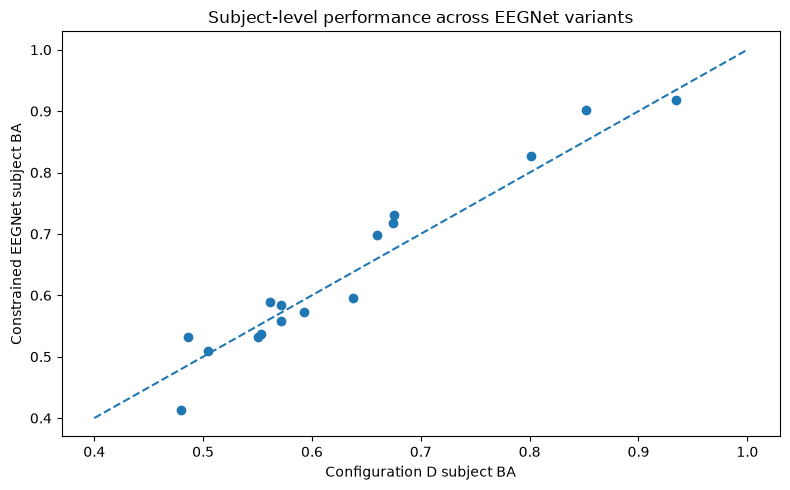

In [38]:
plt.figure(figsize=(8, 5))

plt.scatter(
    subject_comparison["Configuration D"],
    subject_comparison["Constrained EEGNet"]
)

plt.plot(
    [0.4, 1.0],
    [0.4, 1.0],
    linestyle="--"
)

plt.xlabel("Configuration D subject BA")
plt.ylabel("Constrained EEGNet subject BA")
plt.title("Subject-level performance across EEGNet variants")

plt.tight_layout()
plt.show()

### Calculate correlation

In [35]:
correlation = subject_comparison[
    ["Configuration D", "Constrained EEGNet"]
].corr().iloc[0, 1]

print("Subject-performance correlation:", correlation)

Subject-performance correlation: 0.971323042125489


### Save to csv

In [36]:
subject_ba_df.to_csv(
    RESULTS_DIR / "week11b_subject_seed_ba.csv",
    index=False
)

subject_summary_df.to_csv(
    RESULTS_DIR / "week11b_subject_summary.csv",
    index=False
)

## Phase 3B — Results

Validation performance varied substantially between subjects.

For Configuration D, mean subject-level balanced accuracy ranged from approximately
0.48 to 0.93.

For the constrained EEGNet, mean subject-level balanced accuracy ranged from
approximately 0.41 to 0.92.

The same subjects tended to be easy or difficult for both models. Subject-level
performance between Configuration D and constrained EEGNet was highly correlated
(`r ≈ 0.97`).

This indicates that the overall validation BA near 0.63 hides substantial
inter-subject variability. The main cross-subject limitation therefore appears
to be strongly associated with individual subjects.

The constrained EEGNet improved mean subject-level performance for 9 of the
16 validation subjects and reduced it for 7.

Some subjects improved substantially, including subjects 1, 19, 25, 34, and 89,
while others, particularly subjects 3 and 107, performed worse.

Therefore, max-norm did not produce a uniform improvement across subjects.

Combined with Phase 3A, the constrained EEGNet achieved a slightly higher pooled
mean validation BA across seeds (`0.634` vs `0.628`), but also substantially
higher between-seed variability.

The results suggest that further progress may depend less on small optimizer or
regularization changes and more on understanding cross-subject differences and
the representations learned from EEG.

This suggests that future model comparison should investigate whether different
representations, such as CSP/LDA or another established EEG architecture, succeed
on subjects that EEGNet consistently struggles with.